In [1]:
import tensorflow as tf

# Check available physical devices
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

# List all GPUs TensorFlow can see
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.10.0
Num GPUs Available: 1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


def plot_mean_vs_wavelength(*file_paths, wl_min=450, wl_max=700):
    """
    Reads one or more ENVI ASCII Plot Files and:
      1) Plots mean reflectance vs wavelength for each file.
      2) If exactly two files are provided:
         a) Plots the ratio of the second file divided by the first on the same axes.
         b) Also produces a separate figure showing only that ratio.
      3) All curves are filtered to wl_min–wl_max (inclusive) and use solid lines (no markers).

    Parameters
    ----------
    *file_paths : str
        One or more paths to ASCII files containing two columns: wavelength and mean reflectance.
    wl_min : float
        Minimum wavelength (nm) for filtering.
    wl_max : float
        Maximum wavelength (nm) for filtering.
    """
    # flatten if a single list/tuple is passed
    if len(file_paths) == 1 and isinstance(file_paths[0], (list, tuple)):
        file_paths = file_paths[0]

    # load each dataset
    datasets = []
    for fp in file_paths:
        path = Path(fp).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f"File not found: {path}")
        wl_vals, mean_vals = [], []
        with path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                try:
                    wl = float(parts[0])
                    m = float(parts[1])
                except ValueError:
                    continue
                if wl_min <= wl <= wl_max:
                    wl_vals.append(wl)
                    mean_vals.append(m)
        if not wl_vals:
            raise ValueError(f"No data in {wl_min}-{wl_max} nm range for {path.name}")
        datasets.append((path.stem, np.array(wl_vals), np.array(mean_vals)))

    # --- Figure 1: reflectance curves + ratio (if two files) ---
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    for name, wl, mean in datasets:
        ax1.plot(wl, mean, label=name, linestyle="-")
    ratio = None
    if len(datasets) == 2:
        name0, wl0, mean0 = datasets[0]
        name1, wl1, mean1 = datasets[1]
        # interpolate second onto first's wavelengths if needed
        if not np.array_equal(wl0, wl1):
            mean1 = np.interp(wl0, wl1, mean1)
        ratio = mean1 / mean0
        ax1.plot(wl0, ratio, label=f"{name1}/{name0}", linestyle="-")
    ax1.set_xlabel("Wavelength (nm)")
    ax1.set_ylabel("Mean Reflectance / Ratio")
    ax1.set_title(
        f"Reflectance{' & Ratio' if ratio is not None else ''} ({wl_min}–{wl_max} nm)"
    )
    ax1.grid(True)
    ax1.legend(title="Dataset")
    fig1.tight_layout()
    plt.show()

    # --- Figure 2: separate ratio plot if applicable ---
    if ratio is not None:
        fig2, ax2 = plt.subplots(figsize=(8, 5))
        ax2.plot(wl0, ratio, linestyle="-")
        ax2.set_xlabel("Wavelength (nm)")
        ax2.set_ylabel(f"{name1}/{name0}")
        ax2.set_title(f"Ratio of {name1} to {name0} ({wl_min}–{wl_max} nm)")
        ax2.grid(True)
        ax2.set_ylim(0, 4)
        fig2.tight_layout()
        plt.show()

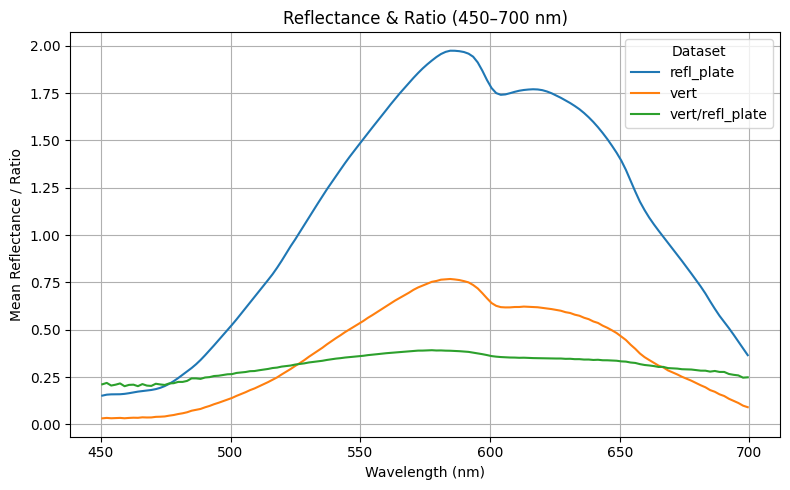

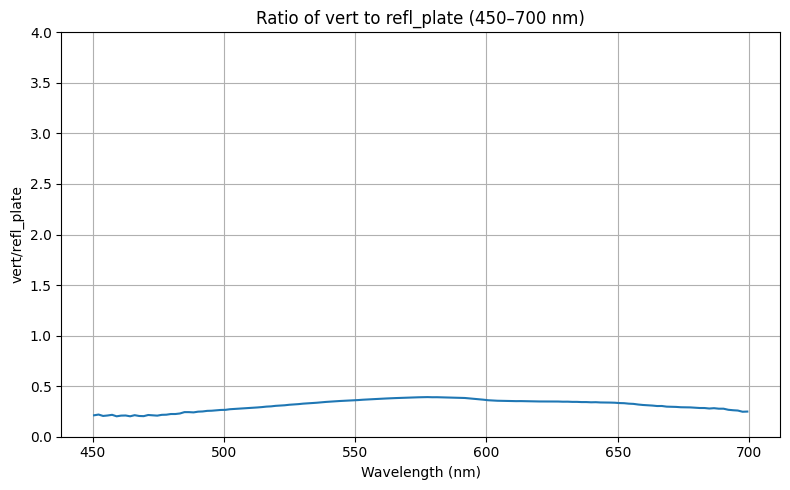

In [23]:
# Example usage:
refl_plate = r"C:\Users\Erik Liu\Downloads\refl_plate.txt"
vert = r"C:\Users\Erik Liu\Downloads\vert.txt"

plot_mean_vs_wavelength(refl_plate, vert)